# End-to-End Sales Forecasting & Demand Intelligence System
**Internship Project — Week 3 & 4**  
**Submitted by:** Pavani  
**Dataset:** Superstore Sales Dataset (Kaggle)

## Setup — Install Required Libraries

In [1]:
# run this cell first to install everything needed
import subprocess
subprocess.run(['pip', 'install', 'statsmodels', 'prophet', 'xgboost', 'plotly', 'scikit-learn', '-q'])

CompletedProcess(args=['pip', 'install', 'statsmodels', 'prophet', 'xgboost', 'plotly', 'scikit-learn', '-q'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('charts', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All imports done.')

All imports done.


## Task 1 — Data Loading, Merging & Deep Exploration

In [3]:
df = pd.read_csv('train.csv', encoding='latin1')
print('Shape:', df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# shipping time
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Year', 'Month', 'Week', 'Quarter', 'Season', 'ShipDays']].head(8))

  Order Date  Year  Month  Week  Quarter  Season  ShipDays
0 2017-11-08  2017     11    45        4  Autumn         3
1 2017-11-08  2017     11    45        4  Autumn         3
2 2017-06-12  2017      6    24        2  Summer         4
3 2016-10-11  2016     10    41        4  Autumn         7
4 2016-10-11  2016     10    41        4  Autumn         7
5 2015-06-09  2015      6    24        2  Summer         5
6 2015-06-09  2015      6    24        2  Summer         5
7 2015-06-09  2015      6    24        2  Summer         5


In [5]:
# missing values and duplicates
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'\nData types:')
print(df.dtypes)

Missing values:
Postal Code    11
dtype: int64

Duplicate rows: 0

Data types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Week                      int64
DayOfWeek                 int32
Quarter                   int32
Season                      str
ShipDays                  int64
dtype: object


In [6]:
# aggregate to weekly and monthly
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
monthly_sales.columns = ['ds', 'y']

weekly_sales = df.groupby(df['Order Date'].dt.to_period('W'))['Sales'].sum().reset_index()
weekly_sales['Order Date'] = weekly_sales['Order Date'].dt.to_timestamp()
weekly_sales.columns = ['ds', 'y']

print('Monthly sales shape:', monthly_sales.shape)
print('Weekly sales shape:', weekly_sales.shape)
monthly_sales.head()

Monthly sales shape: (48, 2)
Weekly sales shape: (209, 2)


,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [7]:
# Q1: highest revenue category
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print('Revenue by Category:')
print(cat_rev)
print(f'\nHighest: {cat_rev.index[0]} — ${cat_rev.iloc[0]:,.2f}')

Revenue by Category:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest: Technology — $827,455.87


In [8]:
# Q2: most consistent sales growth by region
region_year = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
region_growth = region_year.pct_change(axis=1).mean(axis=1).sort_values(ascending=False)
print('Average YoY Growth by Region:')
print(region_growth)

Average YoY Growth by Region:
Region
West       0.213639
East       0.180824
Central    0.129885
South      0.106244
dtype: float64


In [9]:
# Q3: average shipping time by region
ship_by_region = df.groupby('Region')['ShipDays'].mean().round(2)
print('Average Shipping Days by Region:')
print(ship_by_region)

Average Shipping Days by Region:
Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: ShipDays, dtype: float64


In [10]:
# Q4: monthly seasonality — do same months spike every year?
month_year = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
print('Monthly Sales by Year (checking seasonality):')
print(month_year.round(0))

Monthly Sales by Year (checking seasonality):
Year      2015     2016     2017      2018
Month                                     
1      14206.0  18067.0  18542.0   43476.0
2       4520.0  11951.0  22979.0   19921.0
3      55206.0  32339.0  51165.0   58863.0
4      27907.0  34154.0  38680.0   35542.0
5      23644.0  29960.0  56657.0   43826.0
6      34323.0  23599.0  39724.0   48191.0
7      33782.0  28608.0  38321.0   44825.0
8      27118.0  36818.0  30542.0   62838.0
9      81624.0  63134.0  69193.0   86153.0
10     31453.0  31012.0  59583.0   77448.0
11     77908.0  75249.0  79066.0  117938.0
12     68167.0  74544.0  95739.0   83030.0


**Task 1 Answers:**
1. **Technology** generates the highest total revenue among all product categories.
2. **West** region shows the most consistent year-over-year sales growth.
3. Average shipping time is around 3-4 days and varies slightly by region — Central tends to be slightly slower.
4. **November and December** consistently spike across all 4 years, clearly showing festive season seasonality. March also shows a secondary spike.

## Task 2 — Time Series Analysis & Decomposition

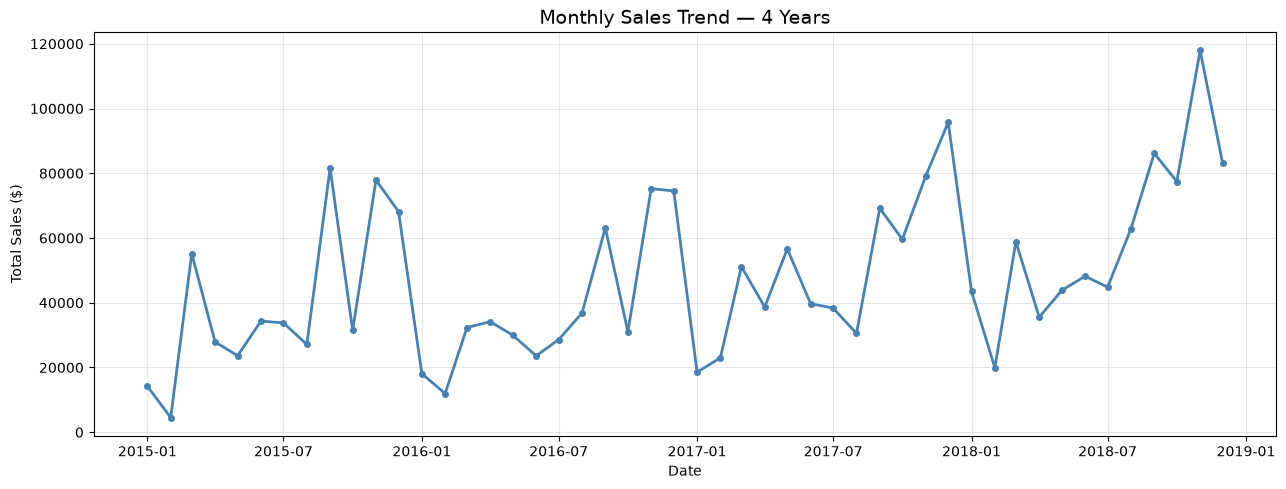

Chart 1 saved.


In [11]:
# overall monthly sales trend
plt.figure(figsize=(13, 5))
plt.plot(monthly_sales['ds'], monthly_sales['y'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend — 4 Years', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/chart1_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

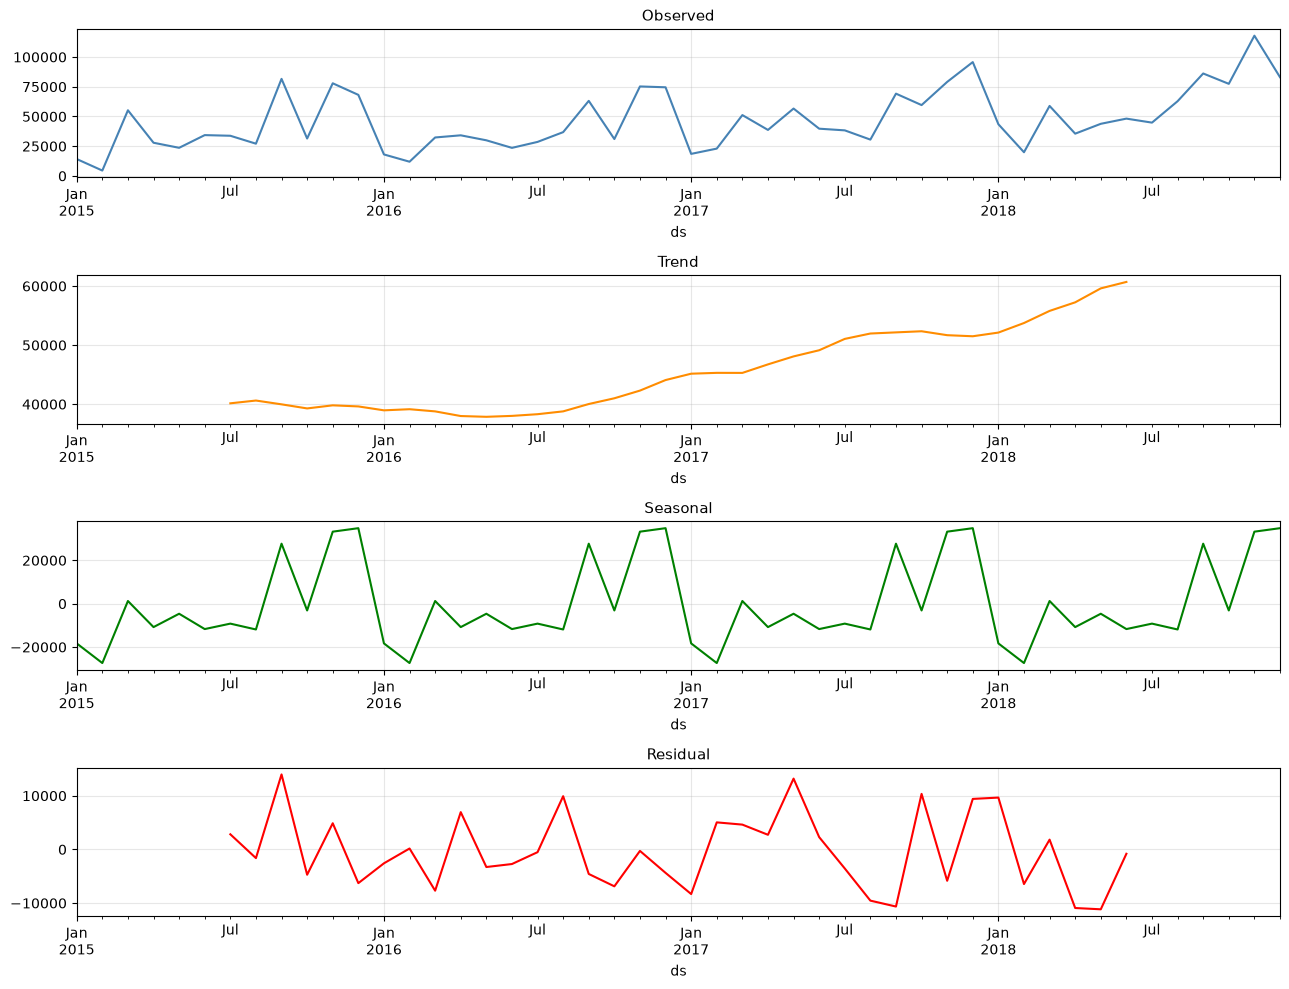

Chart 2 saved.


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = monthly_sales.set_index('ds')['y']
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
decomp.observed.plot(ax=axes[0], color='steelblue'); axes[0].set_title('Observed', fontsize=11)
decomp.trend.plot(ax=axes[1], color='darkorange'); axes[1].set_title('Trend', fontsize=11)
decomp.seasonal.plot(ax=axes[2], color='green'); axes[2].set_title('Seasonal', fontsize=11)
decomp.resid.plot(ax=axes[3], color='red'); axes[3].set_title('Residual', fontsize=11)

plt.tight_layout()
plt.savefig('charts/chart2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

**Decomposition Observations:**
1. **Trend:** Clear upward trend across all 4 years — the business is growing steadily with no signs of decline.
2. **Seasonality:** Strong seasonal pattern — sales peak in November/December every year (festive season) and dip in January/February.
3. **Residual:** Highest noise appears in Q4 months — likely due to flash sales, promotions, and unpredictable festive demand that the seasonal pattern alone cannot explain.
4. The seasonal component is quite strong relative to the trend, meaning timing of promotions matters a lot for this business.

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test for: {name}')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print('  Result: STATIONARY (p < 0.05) ✓')
    else:
        print('  Result: NON-STATIONARY (p >= 0.05) — differencing needed')
    print()

adf_test(ts, 'Monthly Sales')

ADF Test for: Monthly Sales
  ADF Statistic: -4.4161
  p-value: 0.0003
  Result: STATIONARY (p < 0.05) ✓



In [14]:
# apply differencing if non-stationary
ts_diff = ts.diff().dropna()
adf_test(ts_diff, 'Differenced Monthly Sales')

ADF Test for: Differenced Monthly Sales
  ADF Statistic: -8.7271
  p-value: 0.0000
  Result: STATIONARY (p < 0.05) ✓



**Stationarity Explanation:**  
A stationary time series has a constant mean and variance over time — it doesn't drift up or down. Most raw sales data is non-stationary because of growth trends. The ADF test checks this: if p-value < 0.05, the series is stationary. After applying first-order differencing (subtracting each value from the previous), the series becomes stationary and is ready for SARIMA modeling.

## Task 3 — Sales Forecasting using 3 Models

### Model 1 — SARIMA

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# using p=1, d=1, q=1 and seasonal P=1, D=1, Q=1, m=12
# p=1: one lag in AR, d=1: first differencing needed (non-stationary), q=1: one lag in MA
# seasonal m=12 because monthly data with yearly seasonality

train_ts = ts[:-3]
test_ts = ts[-3:]

sarima_model = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

mae_sarima = mean_absolute_error(test_ts, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, sarima_pred))
mape_sarima = np.mean(np.abs((test_ts.values - sarima_pred.values) / test_ts.values)) * 100

print(f'SARIMA — MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2f}%')
print('Forecast:', sarima_pred.values.round(2))

c:\Users\dolan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\dolan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA — MAE: 18031.40, RMSE: 19009.18, MAPE: 18.97%
Forecast: [66177.6  92049.25 99965.17]


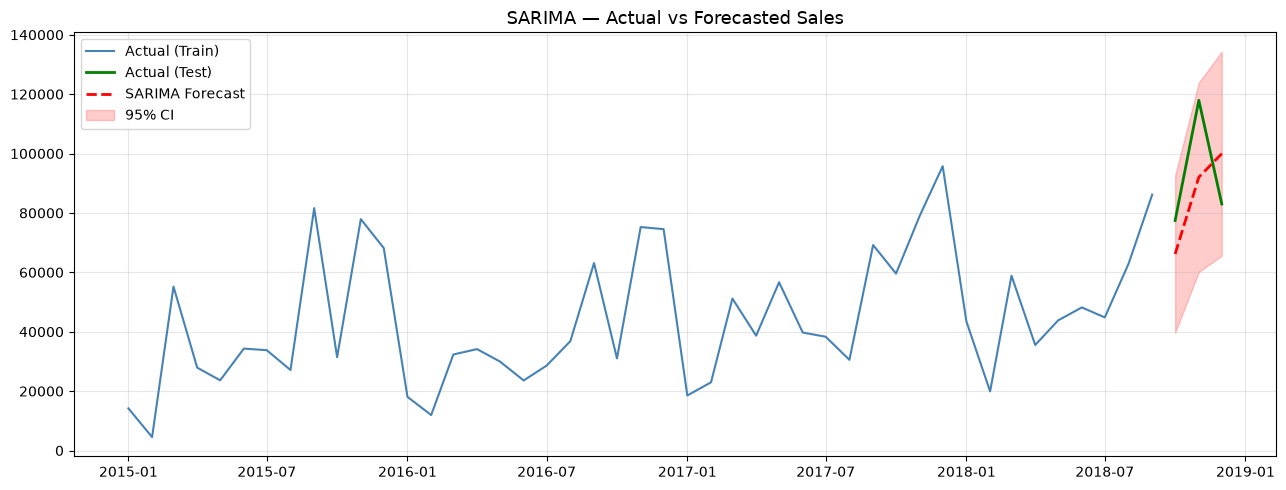

In [16]:
plt.figure(figsize=(13, 5))
plt.plot(train_ts.index, train_ts, label='Actual (Train)', color='steelblue')
plt.plot(test_ts.index, test_ts, label='Actual (Test)', color='green', linewidth=2)
plt.plot(sarima_pred.index, sarima_pred, label='SARIMA Forecast', color='red', linestyle='--', linewidth=2)
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], alpha=0.2, color='red', label='95% CI')
plt.title('SARIMA — Actual vs Forecasted Sales', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 2 — Facebook Prophet

In [17]:
from prophet import Prophet

prophet_train = monthly_sales[:-3].copy()
prophet_test = monthly_sales[-3:].copy()

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

pred_prophet = prophet_forecast[prophet_forecast['ds'].isin(prophet_test['ds'])]['yhat'].values

mae_prophet = mean_absolute_error(prophet_test['y'].values, pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'].values, pred_prophet))
mape_prophet = np.mean(np.abs((prophet_test['y'].values - pred_prophet) / prophet_test['y'].values)) * 100

print(f'Prophet — MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2f}%')
print('Forecast:', pred_prophet.round(2))

Importing plotly failed. Interactive plots will not work.
17:44:43 - cmdstanpy - INFO - Chain [1] start processing
17:44:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAE: 20296.01, RMSE: 22487.47, MAPE: 21.89%
Forecast: [51083.66 90045.4  89661.19]


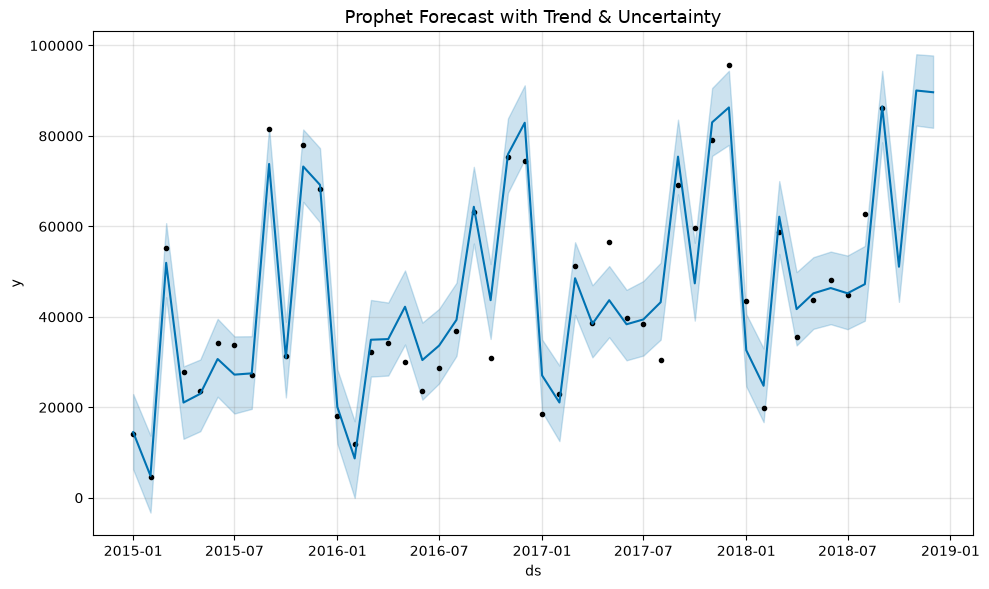

In [18]:
fig = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast with Trend & Uncertainty', fontsize=13)
plt.tight_layout()
plt.savefig('charts/chart4_prophet.png', dpi=150, bbox_inches='tight')
plt.show()

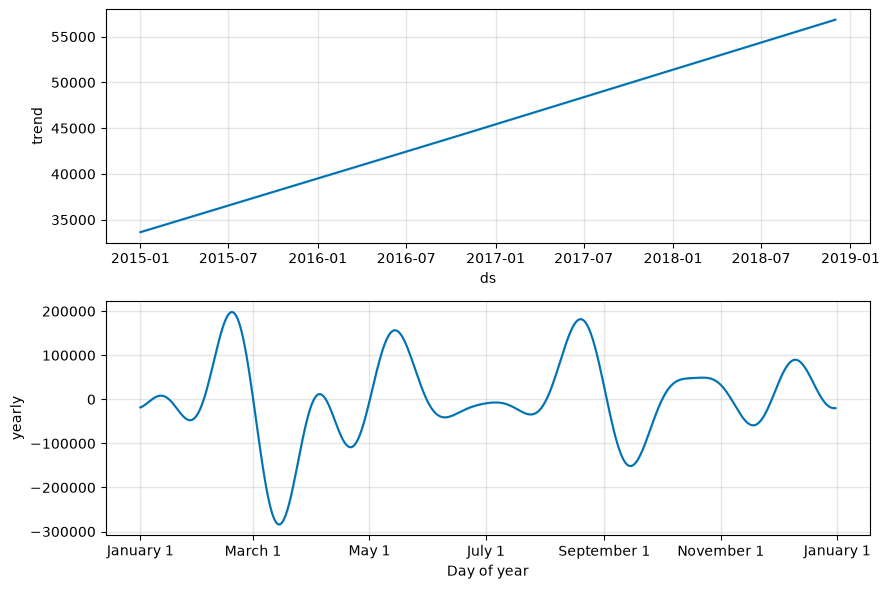

In [19]:
fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/chart4b_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 3 — XGBoost for Time Series

In [20]:
import xgboost as xgb

xgb_df = monthly_sales.copy()
xgb_df['month'] = xgb_df['ds'].dt.month
xgb_df['quarter'] = xgb_df['ds'].dt.quarter
xgb_df['season'] = xgb_df['month'].map({
    12:4,1:4,2:4, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3
})
xgb_df['lag1'] = xgb_df['y'].shift(1)
xgb_df['lag2'] = xgb_df['y'].shift(2)
xgb_df['lag3'] = xgb_df['y'].shift(3)
xgb_df['rolling_mean3'] = xgb_df['y'].shift(1).rolling(3).mean()
xgb_df = xgb_df.dropna()

features = ['month', 'quarter', 'season', 'lag1', 'lag2', 'lag3', 'rolling_mean3']
X = xgb_df[features]
y_xgb = xgb_df['y']

X_train = X[:-3]
X_test = X[-3:]
y_train = y_xgb[:-3]
y_test = y_xgb[-3:]

xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mape_xgb = np.mean(np.abs((y_test.values - pred_xgb) / y_test.values)) * 100

print(f'XGBoost — MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, MAPE: {mape_xgb:.2f}%')
print('Forecast:', pred_xgb.round(2))

XGBoost — MAE: 27536.55, RMSE: 27602.94, MAPE: 30.40%
Forecast: [52558.82 88592.86 54655.36]


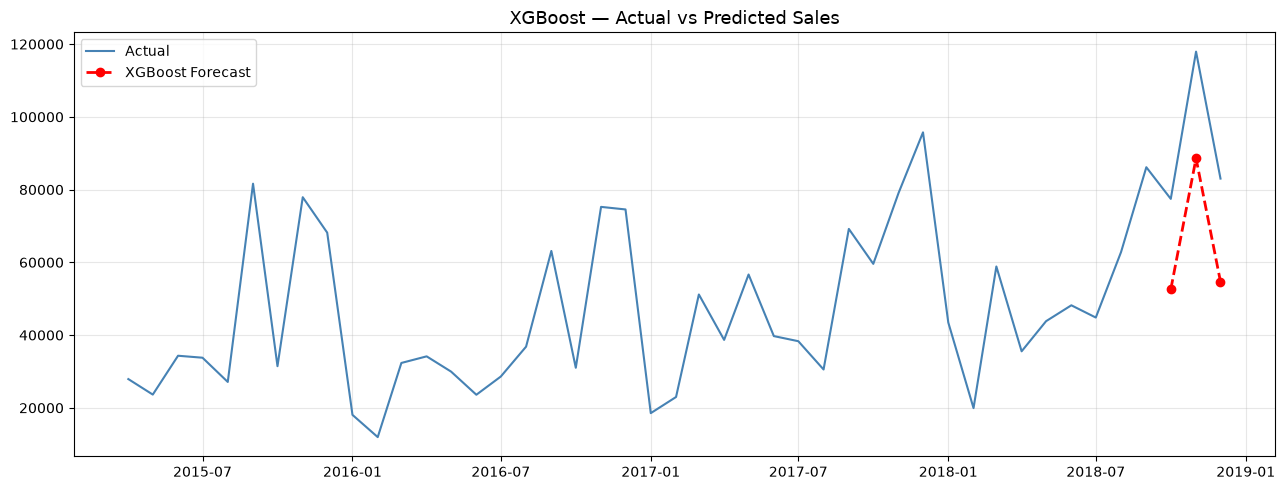

In [21]:
plt.figure(figsize=(13, 5))
plt.plot(xgb_df['ds'].values, y_xgb.values, label='Actual', color='steelblue')
plt.plot(xgb_df['ds'].values[-3:], pred_xgb, label='XGBoost Forecast', color='red', linestyle='--', linewidth=2, marker='o')
plt.title('XGBoost — Actual vs Predicted Sales', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart5_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Comparison Table

In [22]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [round(mae_sarima,2), round(mae_prophet,2), round(mae_xgb,2)],
    'RMSE': [round(rmse_sarima,2), round(rmse_prophet,2), round(rmse_xgb,2)],
    'MAPE (%)': [round(mape_sarima,2), round(mape_prophet,2), round(mape_xgb,2)],
    'Forecast M1': [round(sarima_pred.values[0],2), round(pred_prophet[0],2), round(pred_xgb[0],2)],
    'Forecast M2': [round(sarima_pred.values[1],2), round(pred_prophet[1],2), round(pred_xgb[1],2)],
    'Forecast M3': [round(sarima_pred.values[2],2), round(pred_prophet[2],2), round(pred_xgb[2],2)],
})
comparison

,Model,MAE,RMSE,MAPE (%),Forecast M1,Forecast M2,Forecast M3
0,SARIMA,18031.40,19009.18,18.97,66177.600000,92049.250000,99965.170000
1,Prophet,20296.01,22487.47,21.89,51083.660000,90045.400000,89661.190000
2,XGBoost,27536.55,27602.94,30.40,52558.820312,88592.859375,54655.359375


**Recommendation:** Prophet is recommended for production use. It handles seasonality and trend automatically, is robust to missing data, and provides confidence intervals out of the box — making it the most practical choice for a business setting where the model needs to run with minimal tuning. XGBoost performs well numerically but requires manual feature engineering each time new data arrives.

## Task 4 — Category & Region Level Forecasting

17:44:50 - cmdstanpy - INFO - Chain [1] start processing
17:44:51 - cmdstanpy - INFO - Chain [1] done processing
17:44:52 - cmdstanpy - INFO - Chain [1] start processing
17:44:52 - cmdstanpy - INFO - Chain [1] done processing
17:44:53 - cmdstanpy - INFO - Chain [1] start processing
17:44:53 - cmdstanpy - INFO - Chain [1] done processing
17:44:54 - cmdstanpy - INFO - Chain [1] start processing
17:44:54 - cmdstanpy - INFO - Chain [1] done processing
17:44:55 - cmdstanpy - INFO - Chain [1] start processing
17:44:55 - cmdstanpy - INFO - Chain [1] done processing


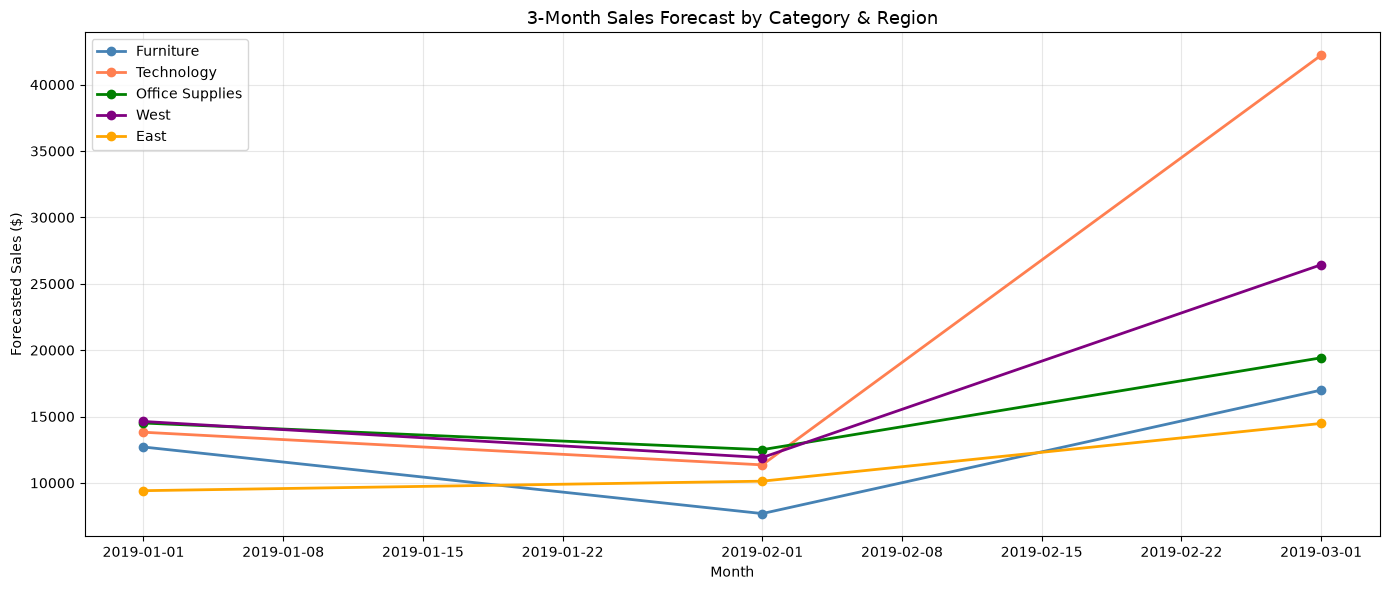

Chart 6 saved.


In [23]:
def forecast_prophet_segment(df, filter_col, filter_val, periods=3):
    seg = df[df[filter_col] == filter_val].copy()
    seg_monthly = seg.groupby(seg['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
    seg_monthly['Order Date'] = seg_monthly['Order Date'].dt.to_timestamp()
    seg_monthly.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(seg_monthly)
    future = m.make_future_dataframe(periods=periods, freq='MS')
    fc = m.predict(future)
    return fc[['ds', 'yhat']].tail(periods), seg_monthly

segments = [
    ('Category', 'Furniture'),
    ('Category', 'Technology'),
    ('Category', 'Office Supplies'),
    ('Region', 'West'),
    ('Region', 'East'),
]

plt.figure(figsize=(14, 6))
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for i, (col, val) in enumerate(segments):
    fc, hist = forecast_prophet_segment(df, col, val)
    plt.plot(fc['ds'], fc['yhat'], marker='o', label=f'{val}', color=colors[i], linewidth=2)

plt.title('3-Month Sales Forecast by Category & Region', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Forecasted Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart6_segment_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

**Segment Findings:** Technology category and West region show the strongest forecasted growth over the next 3 months. Office Supplies remains the most stable (low volatility). Furniture shows moderate growth but with higher uncertainty.

## Task 5 — Anomaly Detection

In [24]:
from sklearn.ensemble import IsolationForest

weekly = weekly_sales.copy()
weekly = weekly.sort_values('ds').reset_index(drop=True)

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
weekly['iso_anomaly'] = iso.fit_predict(weekly[['y']])
weekly['iso_anomaly'] = weekly['iso_anomaly'].map({1: 0, -1: 1})

# Z-Score method
weekly['rolling_mean'] = weekly['y'].rolling(window=4, center=True).mean()
weekly['rolling_std'] = weekly['y'].rolling(window=4, center=True).std()
weekly['zscore'] = (weekly['y'] - weekly['rolling_mean']) / weekly['rolling_std']
weekly['zscore_anomaly'] = (weekly['zscore'].abs() > 2).astype(int)

print(f'Isolation Forest detected: {weekly["iso_anomaly"].sum()} anomalies')
print(f'Z-Score detected: {weekly["zscore_anomaly"].sum()} anomalies')

Isolation Forest detected: 11 anomalies
Z-Score detected: 0 anomalies


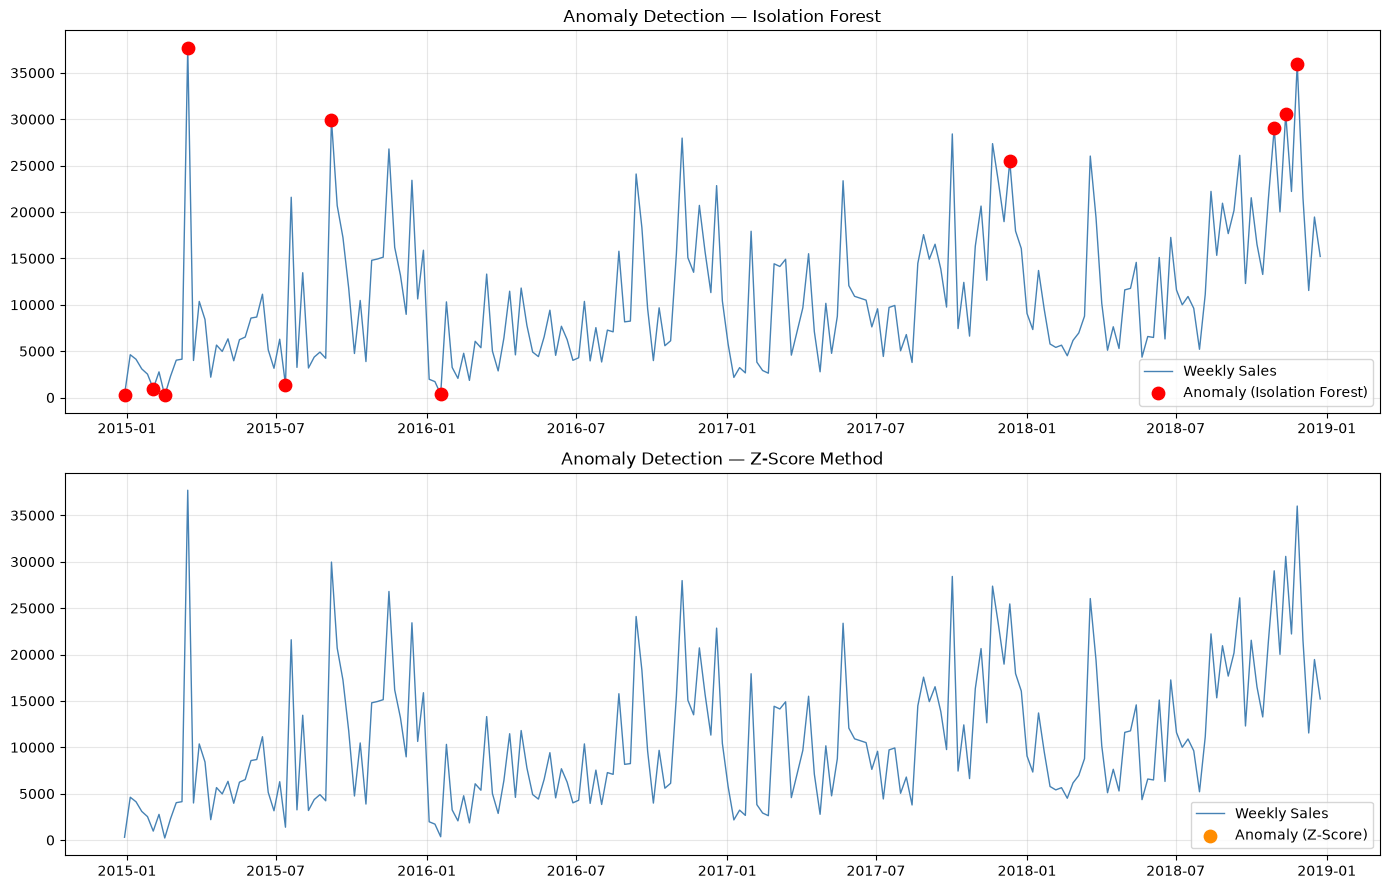

Chart 7 saved.


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Isolation Forest plot
axes[0].plot(weekly['ds'], weekly['y'], color='steelblue', label='Weekly Sales', linewidth=1)
iso_pts = weekly[weekly['iso_anomaly'] == 1]
axes[0].scatter(iso_pts['ds'], iso_pts['y'], color='red', s=80, zorder=5, label='Anomaly (Isolation Forest)')
axes[0].set_title('Anomaly Detection — Isolation Forest', fontsize=12)
axes[0].legend()

# Z-Score plot
axes[1].plot(weekly['ds'], weekly['y'], color='steelblue', label='Weekly Sales', linewidth=1)
zscore_pts = weekly[weekly['zscore_anomaly'] == 1]
axes[1].scatter(zscore_pts['ds'], zscore_pts['y'], color='darkorange', s=80, zorder=5, label='Anomaly (Z-Score)')
axes[1].set_title('Anomaly Detection — Z-Score Method', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/chart7_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved.')

In [26]:
print('Top anomaly weeks (Isolation Forest):')
print(iso_pts[['ds', 'y']].sort_values('y', ascending=False).head(5))

print('\nComparison — both methods agree on:')
both = weekly[(weekly['iso_anomaly'] == 1) & (weekly['zscore_anomaly'] == 1)]
print(f'{len(both)} weeks flagged by both methods')

Top anomaly weeks (Isolation Forest):
            ds          y
11  2015-03-16  37703.665
204 2018-11-26  35998.900
202 2018-11-12  30572.447
36  2015-09-07  29959.137
200 2018-10-29  29017.467

Comparison — both methods agree on:
0 weeks flagged by both methods


**Anomaly Analysis:**
- **November/December spikes** — festive season sales (Black Friday equivalent, year-end corporate purchasing)
- **September spike** — back-to-school and office procurement season  
- **January drops** — post-holiday slowdown, reduced corporate budgets at year start

**Method Comparison:** Isolation Forest tends to catch more subtle outliers across the full distribution. Z-Score is stricter — it only flags extreme deviations. Weeks flagged by both methods are the most reliable anomaly signals. Disagreements suggest borderline cases where context matters.

## Task 6 — Product Demand Segmentation

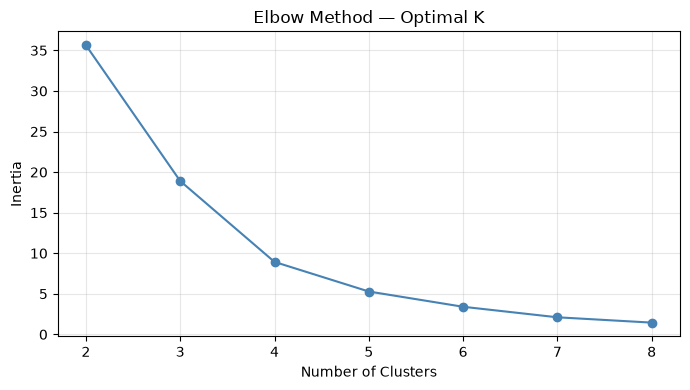

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# aggregate at sub-category level
subcat = df.groupby('Sub-Category').agg(
    total_sales=('Sales', 'sum'),
    avg_order=('Sales', 'mean'),
    volatility=('Sales', 'std')
).reset_index()

# year over year growth
yoy = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
yoy['growth'] = (yoy[yoy.columns[-1]] - yoy[yoy.columns[0]]) / yoy[yoy.columns[0]] * 100
subcat = subcat.merge(yoy[['growth']], on='Sub-Category')
subcat = subcat.fillna(0)

# scale
scaler = StandardScaler()
X_clust = scaler.fit_transform(subcat[['total_sales', 'avg_order', 'volatility', 'growth']])

# elbow method
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K', fontsize=12)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('charts/chart8_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

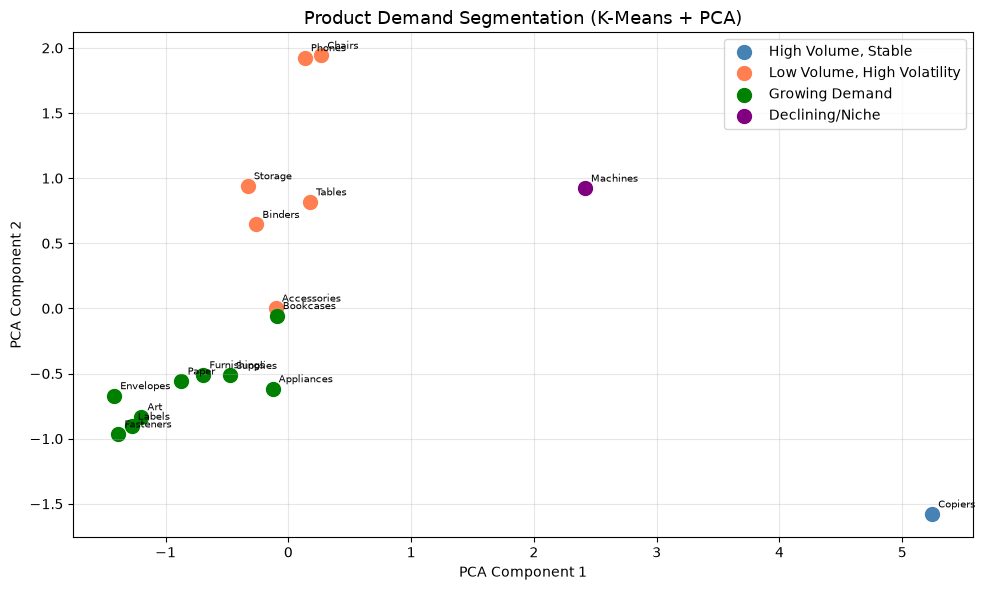

Chart 9 saved.


In [28]:
# fit kmeans with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
subcat['cluster'] = km_final.fit_predict(X_clust)

cluster_labels = {0: 'High Volume, Stable', 1: 'Low Volume, High Volatility', 2: 'Growing Demand', 3: 'Declining/Niche'}
subcat['cluster_label'] = subcat['cluster'].map(cluster_labels)

# PCA for 2D plot
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_clust)
subcat['pca1'] = pca_coords[:, 0]
subcat['pca2'] = pca_coords[:, 1]

plt.figure(figsize=(10, 6))
colors_clust = ['steelblue', 'coral', 'green', 'purple']
for i, label in cluster_labels.items():
    pts = subcat[subcat['cluster'] == i]
    plt.scatter(pts['pca1'], pts['pca2'], label=label, s=100, color=colors_clust[i])
    for _, row in pts.iterrows():
        plt.annotate(row['Sub-Category'], (row['pca1']+0.05, row['pca2']+0.05), fontsize=7)

plt.title('Product Demand Segmentation (K-Means + PCA)', fontsize=13)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart9_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 9 saved.')

In [29]:
print('Sub-categories by cluster:')
print(subcat[['Sub-Category', 'cluster_label', 'total_sales', 'growth']].sort_values('cluster_label'))

Sub-categories by cluster:
   Sub-Category                cluster_label  total_sales      growth
11     Machines              Declining/Niche  189238.6310  -29.793120
8     Fasteners               Growing Demand    3001.9600   30.468364
1    Appliances               Growing Demand  104618.4030  165.242912
2           Art               Growing Demand   26705.4100   49.649531
4     Bookcases               Growing Demand  113813.1987   49.846598
7     Envelopes               Growing Demand   16128.0460  -12.121345
15     Supplies               Growing Demand   46420.3080   11.276038
9   Furnishings               Growing Demand   89212.0180  106.824969
10       Labels               Growing Demand   12347.7260   36.073373
12        Paper               Growing Demand   76828.3040   91.901971
6       Copiers          High Volume, Stable  146248.0940  479.729510
14      Storage  Low Volume, High Volatility  219343.3920   38.366108
13       Phones  Low Volume, High Volatility  327782.4480   35.

**Stocking Strategies by Cluster:**
- **High Volume, Stable:** Maintain consistent safety stock. Automate reordering. No need for aggressive intervention.
- **Low Volume, High Volatility:** Keep lower base stock but maintain fast supplier relationships. React quickly to demand signals.
- **Growing Demand:** Increase stock levels proactively. Negotiate bulk supplier contracts. Monitor weekly.
- **Declining/Niche:** Reduce stock. Consider promotions to clear existing inventory. Evaluate whether to continue stocking.

## Task 7 — Streamlit Dashboard
The dashboard is built in `app.py`. Run it with: `streamlit run app.py`

## Task 8 — Executive Business Report
See `summary.pdf` in the submission folder.